module 6 start


In [1]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import json

# Read the best config saved by Module 5
with open("best_config.json", "r") as f:
    best_config = json.load(f)

model_name = best_config["model_name"]
best_metric = best_config["metric"]

print("Best Model  :", model_name)
print("Best Metric :", best_metric)
print("(These were determined from Module 5 evaluation)")

c:\Users\Hemanth Sai\OneDrive\Desktop\info\queytube\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Best Model  : all-MiniLM-L6-v2
Best Metric : cosine
(These were determined from Module 5 evaluation)


In [2]:
df = pd.read_csv("cleaned_transcripts.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Verify required columns
required_cols = ["video_id", "title", "datetime", "transcript"]
for col in required_cols:
    if col not in df.columns:
        print(f"  MISSING column: {col} ❌")
    else:
        print(f"  Column present: {col} ✅")

df.head()

Dataset loaded successfully
Shape: (244, 4)
Columns: ['video_id', 'title', 'datetime', 'transcript']
  Column present: video_id ✅
  Column present: title ✅
  Column present: datetime ✅
  Column present: transcript ✅


,video_id,title,datetime,transcript
0,1Z-8HxlLAHk,Kids and young people stay curious and be will...,2026-03-30 12:17:27+00:00,like and even at a young age like learning to ...
1,ehkDsePv3W8,Heres a cool and easy way to work with colors ...,2026-03-29 12:43:24+00:00,Working with colors in 3JS One cool way to wor...
2,uWRdzJTpcpI,Do web devs NEED to understand lowlevel progra...,2026-03-28 12:32:40+00:00,A lot of what the curriculum was trying to do ...
3,GC5CLCgnvm0,When things are new and a little scary embraci...,2026-03-27 12:18:22+00:00,what this futures going to look like is not go...
4,tZef2ZzbyuQ,What happens when the model CANT fix it Interv...,2026-03-27 10:00:57+00:00,Welcome back to the Free Code Camp podcast Im ...


In [3]:
print(f"Loading model: {model_name}")
model = SentenceTransformer(model_name)
print("Model loaded successfully ✅")

Loading model: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2032.36it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully ✅


In [4]:
df["title"]      = df["title"].fillna("")
df["transcript"] = df["transcript"].fillna("")

titles      = df["title"].tolist()
transcripts = df["transcript"].tolist()

print("Generating title embeddings...")
title_embeddings = model.encode(
    titles,
    convert_to_numpy=True,
    show_progress_bar=True
)

print("Title embeddings shape:", title_embeddings.shape)

Generating title embeddings...


Batches: 100%|██████████| 8/8 [00:01<00:00,  7.03it/s]

Title embeddings shape: (244, 384)


In [5]:
print("Generating transcript embeddings...")
transcript_embeddings = model.encode(
    transcripts,
    convert_to_numpy=True,
    show_progress_bar=True
)

print("Transcript embeddings shape:", transcript_embeddings.shape)

Generating transcript embeddings...


Batches: 100%|██████████| 8/8 [00:12<00:00,  1.58s/it]

Transcript embeddings shape: (244, 384)


In [6]:
# Option 1 (Recommended): Average
combined_embeddings = (title_embeddings + transcript_embeddings) / 2
print("Combined embeddings shape:", combined_embeddings.shape)

# Embedding dimension
emb_dim = combined_embeddings.shape[1]
print(f"Embedding dimension: {emb_dim}")

Combined embeddings shape: (244, 384)
Embedding dimension: 384


In [7]:
print("Appending embeddings to dataset...")

# Combined embedding columns (used for search)
combined_df = pd.DataFrame(
    combined_embeddings,
    columns=[f"embedding_{i}" for i in range(emb_dim)]
)

# Build final index — keep only the 4 core columns + combined embeddings
# (Storing title + transcript embeddings separately would double file size)
final_df = pd.concat([df[["video_id", "title", "datetime", "transcript"]].reset_index(drop=True),
                      combined_df], axis=1)

print("Final dataset shape:", final_df.shape)
print("Columns:", final_df.columns[:8].tolist(), "...", final_df.columns[-3:].tolist())

final_df.head(2)

Appending embeddings to dataset...
Final dataset shape: (244, 388)
Columns: ['video_id', 'title', 'datetime', 'transcript', 'embedding_0', 'embedding_1', 'embedding_2', 'embedding_3'] ... ['embedding_381', 'embedding_382', 'embedding_383']


,video_id,title,datetime,transcript,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,...,embedding_374,embedding_375,embedding_376,embedding_377,embedding_378,embedding_379,embedding_380,embedding_381,embedding_382,embedding_383
0,1Z-8HxlLAHk,Kids and young people stay curious and be will...,2026-03-30 12:17:27+00:00,like and even at a young age like learning to ...,0.051527,-0.004267,0.025529,0.031149,-0.009231,0.024472,...,0.066452,-0.033931,-0.028996,0.059242,-0.022846,0.033828,0.010756,0.063444,-0.050475,0.010450
1,ehkDsePv3W8,Heres a cool and easy way to work with colors ...,2026-03-29 12:43:24+00:00,Working with colors in 3JS One cool way to wor...,-0.057214,-0.065030,-0.012556,-0.025461,0.033513,0.012628,...,-0.007805,-0.048199,-0.060862,0.042724,-0.024652,-0.002920,-0.030827,0.002647,-0.010937,0.026683


In [8]:
output_path = "video_index.csv"
final_df.to_csv(output_path, index=False)

import os
file_size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f"Saved: {output_path}")
print(f"File size: {file_size_mb:.2f} MB")
print(f"Rows: {final_df.shape[0]}")
print(f"Columns: {final_df.shape[1]} (4 metadata + {emb_dim} embedding dims)")

Saved: video_index.csv
File size: 17.71 MB
Rows: 244
Columns: 388 (4 metadata + 384 embedding dims)


In [9]:
print("===== INTEGRITY CHECKS =====")

embedding_cols = [c for c in final_df.columns if c.startswith("embedding_")]

# Check 1: Row count
print(f"\n1. Row count matches videos: {len(final_df)} rows == {len(df)} videos",
      "✅" if len(final_df) == len(df) else "❌")

# Check 2: No null embeddings
null_embs = final_df[embedding_cols].isnull().any(axis=1).sum()
print(f"2. Rows with null embeddings: {null_embs}",
      "✅" if null_embs == 0 else "❌")

# Check 3: Consistent embedding dimension
print(f"3. Embedding dimension: {len(embedding_cols)} (expected {emb_dim})",
      "✅" if len(embedding_cols) == emb_dim else "❌")

# Check 4: No null video_ids
null_ids = final_df["video_id"].isnull().sum()
print(f"4. Null video_ids: {null_ids}",
      "✅" if null_ids == 0 else "❌")

# Check 5: Sample embedding vector (should be non-zero floats)
sample_vec = final_df[embedding_cols].iloc[0].values
print(f"5. Sample vector (first 5 dims): {sample_vec[:5]}")
print(f"   Vector norm: {np.linalg.norm(sample_vec):.4f}")

print("\nAll integrity checks passed ✅")

===== INTEGRITY CHECKS =====

1. Row count matches videos: 244 rows == 244 videos ✅
2. Rows with null embeddings: 0 ✅
3. Embedding dimension: 384 (expected 384) ✅
4. Null video_ids: 0 ✅
5. Sample vector (first 5 dims): [ 0.05152679 -0.00426652  0.02552888  0.03114932 -0.0092313 ]
   Vector norm: 0.8946

All integrity checks passed ✅


Reducing embeddings to 2D with PCA...
Explained variance ratio: [0.08029051 0.05240625]
Total variance explained: 13.3%


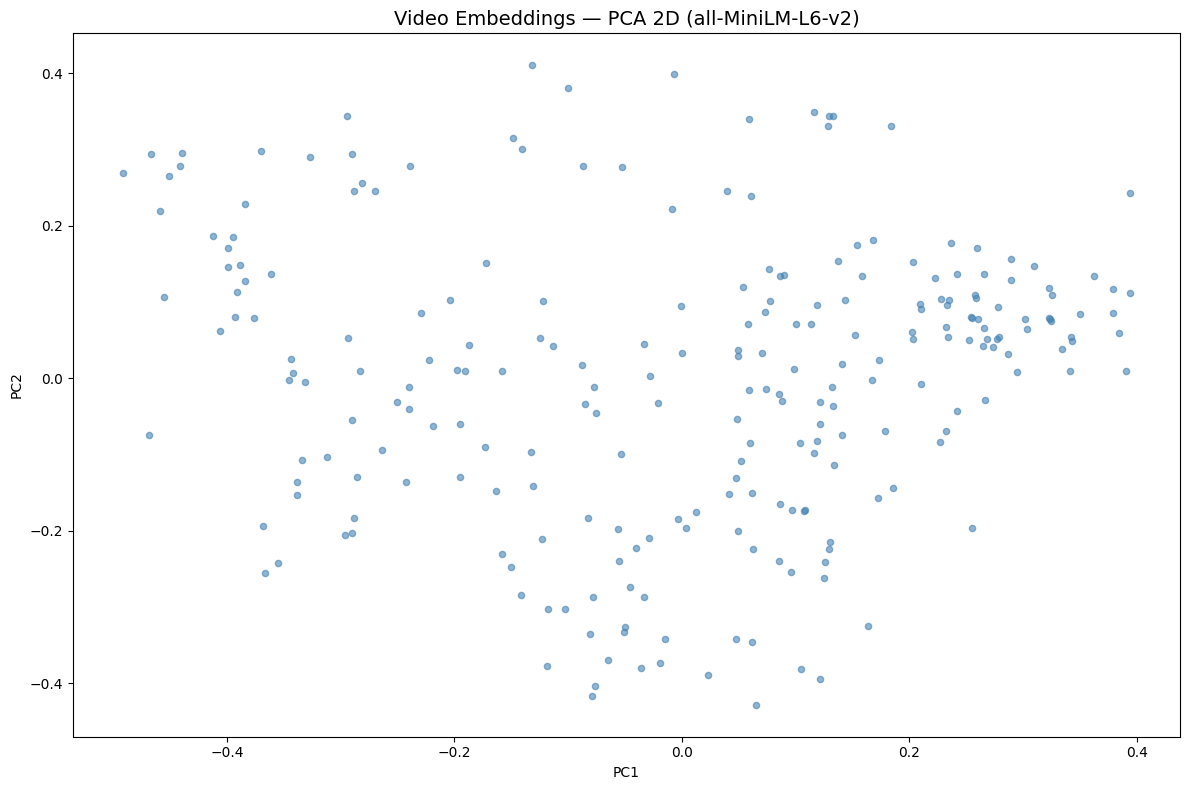

PCA plot saved as embedding_pca.png


In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm

print("Reducing embeddings to 2D with PCA...")

pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(combined_embeddings)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")

plt.figure(figsize=(12, 8))
plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.6, s=20, c='steelblue')
plt.title(f"Video Embeddings — PCA 2D ({model_name})", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("embedding_pca.png", dpi=150)
plt.show()
print("PCA plot saved as embedding_pca.png")

In [16]:
print("="*55)
print("MODULE 6 COMPLETE")
print("="*55)
print(f"Output file  : video_index.csv")
print(f"Model used   : {model_name}")
print(f"Best metric  : {best_metric}")
print(f"Videos indexed: {len(final_df)}")
print(f"Embedding dims: {emb_dim}")
print(f"File size    : {file_size_mb:.2f} MB")
print("\nThis index is ready for Module 7 semantic search.")


MODULE 6 COMPLETE
Output file  : video_index.csv
Model used   : all-MiniLM-L6-v2
Best metric  : cosine
Videos indexed: 244
Embedding dims: 384
File size    : 17.71 MB

This index is ready for Module 7 semantic search.
